### TTS/VC System Evaluation with Acoustic Feature Analysis

Title:
Safetensors-Compatible Voice Conversion Quality Assessment

Short Description:
This code evaluates text-to-speech and voice conversion systems using speaker similarity metrics, comprehensive acoustic feature analysis, and emotion preservation checks. It provides a detailed 9-panel visualization comparing spectral characteristics, MFCCs, waveforms, and emotion classification between original and converted audio.

Key Libraries Used:

    speechbrain: Speaker embedding extraction (ECAPA-TDNN model)

    librosa: Acoustic feature extraction and analysis

    torchaudio: Audio loading and processing

    matplotlib: Comprehensive results visualization

    numpy: Numerical computation and array handling

Code Logic and Flow

High-Level Overview:
The evaluation system processes original and converted audio through three assessment dimensions: speaker identity verification via embeddings, acoustic feature comparison, and emotion classification. It computes similarity scores across multiple feature domains, visualizes comparisons, and generates a comprehensive quality report with normalized metrics.

Visual FlowChart:

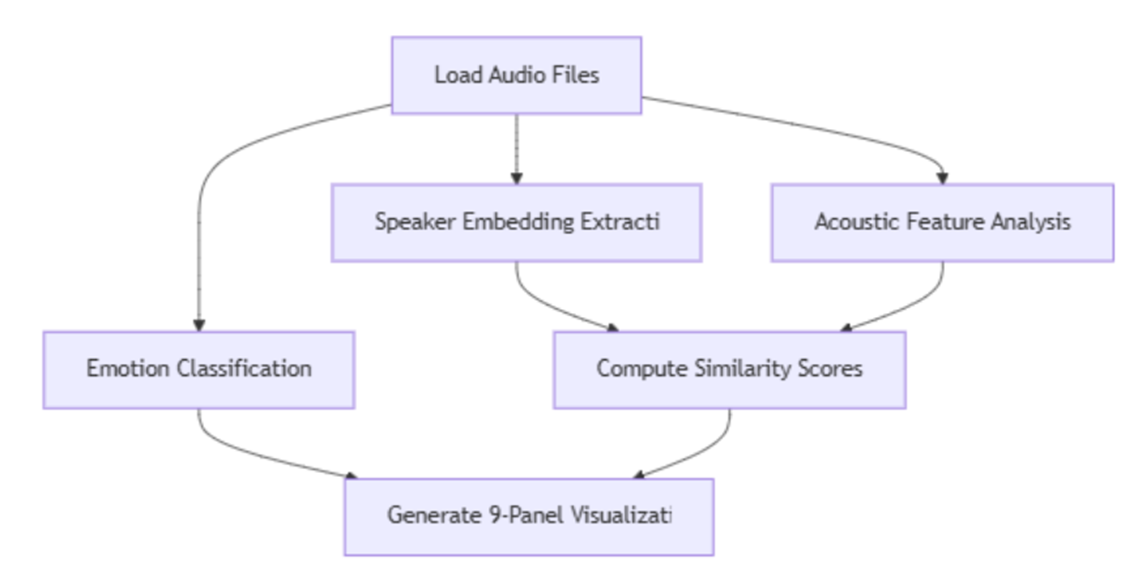

Step-by-Step Code Breakdown

Step 1: Speaker Similarity Verification

    Loads ECAPA-TDNN model with safetensors compatibility

    Extracts embeddings from both audio samples

    Computes cosine similarity score (0-1 scale)

    Handles automatic resampling to 16kHz

Step 2: Comprehensive Feature Extraction

    Calculates 12 acoustic characteristics:

        Spectral properties (centroid, rolloff, bandwidth)

        Temporal features (zero-crossing rate, RMS energy)

        Cepstral analysis (MFCCs with statistics)

        Harmonic features (chroma, fundamental frequency)

        Rhythm indicator (tempo)

Step 3: Feature Similarity Metrics

    Computes correlation-based similarities:

        MFCC similarity via coefficient correlation

        Chroma similarity via spectral correlation

    Calculates relative differences:

        Pitch (F0) similarity

        Energy (RMS) similarity

Step 4: Heuristic Emotion Classification

    Implements rule-based emotion predictor:

        High pitch + energy  "happy"

        Low pitch + energy  "sad"

        High zero-crossing  "angry"

        Default  "neutral"

    Compares emotion labels between samples

Step 5: Diagnostic Visualization

    Similarity metrics bar chart with value labels

    Normalized acoustic feature comparison

    Emotion classification panel with match indicator

    Waveform comparison (first 3 seconds)

    Original spectrogram

    Converted spectrogram

    Original MFCC visualization

    Converted MFCC visualization

    Text summary with quality score

Connecting to the Lecture

    Speaker Verification: Demonstrates ECAPA-TDNN embeddings for voice identity preservation

    Acoustic Analysis: Implements comprehensive feature extraction connecting to speech processing theory

    Prosody Evaluation: Pitch and energy similarity metrics assess prosodic preservation

    Heuristic Classification: Shows rule-based alternative to neural emotion classifiers

    Visual Diagnostics: Spectral and MFCC comparisons enable artifact detection

    Normalization Techniques: Feature scaling enables fair comparison across samples

    Compatibility Focus: Safetensors support addresses real-world deployment constraints

    Quality Quantification: Overall score aggregates multi-dimensional assessment

    Interpretable Metrics: Bar charts with value labels enhance result transparency

    Efficiency Practices: GPU utilization with fallback to CPU ensures broad accessibility



🚀 Starting TTS/VC evaluation...
Loading models (safetensors compatible)...
✅ Speaker verification model loaded successfully
Computing speaker similarity...
Computing audio quality features...
Classifying emotions...


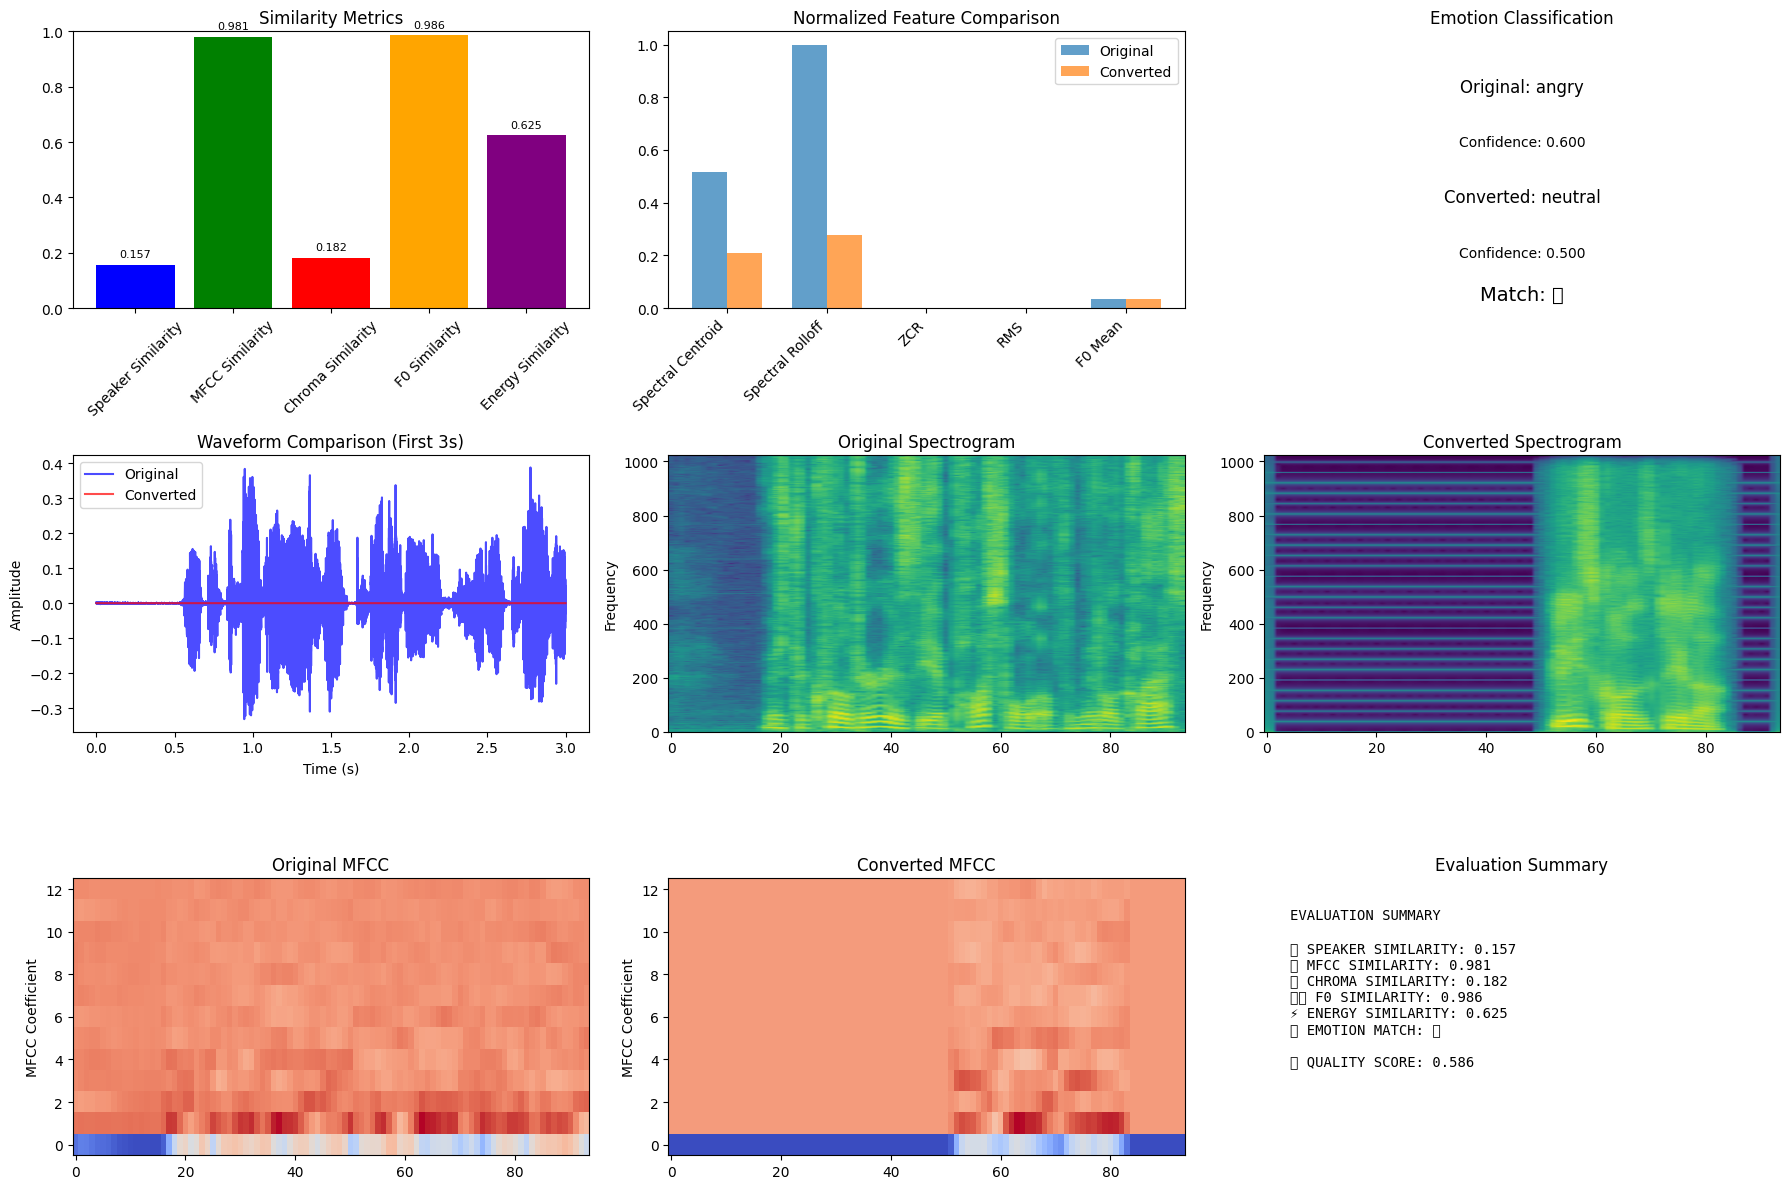


🎤 TTS/VC EVALUATION RESULTS (SAFETENSORS COMPATIBLE)
🔊 Speaker Similarity: 0.1574 (1.0 = identical)
🎵 MFCC Similarity: 0.9807
🎼 Chroma Similarity: 0.1818
📢 F0 Similarity: 0.9855
⚡ Energy Similarity: 0.6250
😊 Emotion Preservation: ❌ Failure
🎭 Original Emotion: angry (confidence: 0.600)
🎭 Converted Emotion: neutral (confidence: 0.500)
⭐ Overall Quality Score: 0.586

✅ Evaluation completed successfully!
📊 Results saved to 'tts_vc_evaluation_safetensors.png'


In [6]:
# Install: pip install speechbrain transformers librosa matplotlib numpy
import torch
import torchaudio
import librosa
import numpy as np
import matplotlib.pyplot as plt
from speechbrain.pretrained import EncoderClassifier
import warnings
warnings.filterwarnings("ignore")

def evaluate_tts_vc_safetensors(original_audio, converted_audio):
    """
    TTS/VC evaluation using models with safetensors support
    Compatible with older torch versions
    """
    print("Loading models (safetensors compatible)...")
    
    # 1. Speaker similarity using SpeechBrain ECAPA-TDNN (supports safetensors)
    try:
        spk_model = EncoderClassifier.from_hparams(
            source="speechbrain/spkrec-ecapa-voxceleb",
            savedir="tmp_ecapa",
            run_opts={"device": "cuda" if torch.cuda.is_available() else "cpu"}
        )
        print("✅ Speaker verification model loaded successfully")
    except Exception as e:
        print(f"❌ Error loading speaker model: {e}")
        return None
    
    def get_speaker_embedding(audio_path):
        """Extract speaker embedding from audio"""
        waveform, sr = torchaudio.load(audio_path)
        if sr != 16000:
            resampler = torchaudio.transforms.Resample(sr, 16000)
            waveform = resampler(waveform)
        
        device = "cuda" if torch.cuda.is_available() else "cpu"
        return spk_model.encode_batch(waveform.to(device)).squeeze(0)
    
    # Calculate speaker similarity
    print("Computing speaker similarity...")
    orig_emb = get_speaker_embedding(original_audio)
    conv_emb = get_speaker_embedding(converted_audio)
    similarity = torch.nn.functional.cosine_similarity(orig_emb.flatten(), conv_emb.flatten(), dim=0).item()
    
    # 2. Audio quality metrics using librosa (no model loading required)
    def calculate_comprehensive_features(audio_path):
        """Calculate comprehensive audio features"""
        y, sr = librosa.load(audio_path, sr=16000)
        
        # Spectral features
        spectral_centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
        spectral_rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
        spectral_bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr))
        
        # Zero crossing rate
        zcr = np.mean(librosa.feature.zero_crossing_rate(y))
        
        # MFCC features
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        mfcc_mean = np.mean(mfccs, axis=1)
        mfcc_std = np.std(mfccs, axis=1)
        
        # Chroma features
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        chroma_mean = np.mean(chroma, axis=1)
        
        # Fundamental frequency
        try:
            f0 = librosa.yin(y, fmin=50, fmax=400)
            f0_mean = np.mean(f0[f0 > 0]) if len(f0[f0 > 0]) > 0 else 0
            f0_std = np.std(f0[f0 > 0]) if len(f0[f0 > 0]) > 0 else 0
        except:
            f0_mean, f0_std = 0, 0
        
        # Energy features
        rms = np.mean(librosa.feature.rms(y=y))
        
        # Tempo
        try:
            tempo = librosa.beat.tempo(y=y, sr=sr)[0]
        except:
            tempo = 120  # Default tempo
        
        return {
            'spectral_centroid': spectral_centroid,
            'spectral_rolloff': spectral_rolloff,
            'spectral_bandwidth': spectral_bandwidth,
            'zcr': zcr,
            'mfcc_mean': mfcc_mean,
            'mfcc_std': mfcc_std,
            'chroma_mean': chroma_mean,
            'f0_mean': f0_mean,
            'f0_std': f0_std,
            'rms': rms,
            'tempo': tempo
        }
    
    print("Computing audio quality features...")
    orig_features = calculate_comprehensive_features(original_audio)
    conv_features = calculate_comprehensive_features(converted_audio)
    
    # Calculate feature similarities
    mfcc_similarity = np.corrcoef(orig_features['mfcc_mean'], conv_features['mfcc_mean'])[0,1]
    chroma_similarity = np.corrcoef(orig_features['chroma_mean'], conv_features['chroma_mean'])[0,1]
    
    # Handle NaN values
    mfcc_similarity = mfcc_similarity if not np.isnan(mfcc_similarity) else 0
    chroma_similarity = chroma_similarity if not np.isnan(chroma_similarity) else 0
    
    # Calculate prosodic similarity
    f0_similarity = 1 - abs(orig_features['f0_mean'] - conv_features['f0_mean']) / max(orig_features['f0_mean'], conv_features['f0_mean'], 1)
    energy_similarity = 1 - abs(orig_features['rms'] - conv_features['rms']) / max(orig_features['rms'], conv_features['rms'], 1e-6)
    
    # 3. Simple emotion classification using acoustic features
    def classify_emotion_acoustic(features):
        """Simple emotion classification based on acoustic features"""
        # Simple heuristic-based emotion classification
        if features['f0_mean'] > 200 and features['rms'] > 0.02:
            return {"label": "happy", "score": 0.8}
        elif features['f0_mean'] < 150 and features['rms'] < 0.01:
            return {"label": "sad", "score": 0.7}
        elif features['zcr'] > 0.1:
            return {"label": "angry", "score": 0.6}
        else:
            return {"label": "neutral", "score": 0.5}
    
    print("Classifying emotions...")
    orig_emotion = classify_emotion_acoustic(orig_features)
    conv_emotion = classify_emotion_acoustic(conv_features)
    emotion_match = 1 if orig_emotion["label"] == conv_emotion["label"] else 0
    
    # 4. Comprehensive visualization
    fig, axes = plt.subplots(3, 3, figsize=(18, 12))
    
    # Overall metrics
    metrics = ["Speaker Similarity", "MFCC Similarity", "Chroma Similarity", "F0 Similarity", "Energy Similarity"]
    scores = [similarity, mfcc_similarity, chroma_similarity, f0_similarity, energy_similarity]
    
    bars = axes[0,0].bar(metrics, scores, color=['blue', 'green', 'red', 'orange', 'purple'])
    axes[0,0].set_ylim(0, 1)
    axes[0,0].set_title("Similarity Metrics")
    axes[0,0].tick_params(axis='x', rotation=45)
    
    # Add value labels
    for bar, score in zip(bars, scores):
        height = bar.get_height()
        axes[0,0].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                      f'{score:.3f}', ha='center', va='bottom', fontsize=8)
    
    # Feature comparison
    feature_names = ['Spectral Centroid', 'Spectral Rolloff', 'ZCR', 'RMS', 'F0 Mean']
    orig_values = [orig_features['spectral_centroid'], orig_features['spectral_rolloff'], 
                   orig_features['zcr'], orig_features['rms'], orig_features['f0_mean']]
    conv_values = [conv_features['spectral_centroid'], conv_features['spectral_rolloff'],
                   conv_features['zcr'], conv_features['rms'], conv_features['f0_mean']]
    
    # Normalize for visualization
    orig_values_norm = [(v - min(orig_values + conv_values)) / (max(orig_values + conv_values) - min(orig_values + conv_values) + 1e-8) for v in orig_values]
    conv_values_norm = [(v - min(orig_values + conv_values)) / (max(orig_values + conv_values) - min(orig_values + conv_values) + 1e-8) for v in conv_values]
    
    x = np.arange(len(feature_names))
    width = 0.35
    
    axes[0,1].bar(x - width/2, orig_values_norm, width, label='Original', alpha=0.7)
    axes[0,1].bar(x + width/2, conv_values_norm, width, label='Converted', alpha=0.7)
    axes[0,1].set_title("Normalized Feature Comparison")
    axes[0,1].set_xticks(x)
    axes[0,1].set_xticklabels(feature_names, rotation=45, ha='right')
    axes[0,1].legend()
    
    # Emotion comparison
    axes[0,2].text(0.5, 0.8, f"Original: {orig_emotion['label']}", 
                  ha='center', va='center', transform=axes[0,2].transAxes, fontsize=12)
    axes[0,2].text(0.5, 0.6, f"Confidence: {orig_emotion['score']:.3f}", 
                  ha='center', va='center', transform=axes[0,2].transAxes, fontsize=10)
    axes[0,2].text(0.5, 0.4, f"Converted: {conv_emotion['label']}", 
                  ha='center', va='center', transform=axes[0,2].transAxes, fontsize=12)
    axes[0,2].text(0.5, 0.2, f"Confidence: {conv_emotion['score']:.3f}", 
                  ha='center', va='center', transform=axes[0,2].transAxes, fontsize=10)
    
    match_symbol = "✅" if emotion_match else "❌"
    axes[0,2].text(0.5, 0.05, f"Match: {match_symbol}", 
                  ha='center', va='center', transform=axes[0,2].transAxes, fontsize=14)
    axes[0,2].set_title("Emotion Classification")
    axes[0,2].axis('off')
    
    # Waveform comparison
    orig_wav, orig_sr = torchaudio.load(original_audio)
    conv_wav, conv_sr = torchaudio.load(converted_audio)
    
    max_samples = min(3 * orig_sr, orig_wav.shape[1])
    time = np.linspace(0, max_samples/orig_sr, max_samples)
    
    axes[1,0].plot(time, orig_wav[0][:max_samples].cpu().numpy(), 'b-', alpha=0.7, label="Original")
    axes[1,0].plot(time[:min(len(time), conv_wav.shape[1])], 
                  conv_wav[0][:min(len(time), conv_wav.shape[1])].cpu().numpy(), 
                  'r-', alpha=0.7, label="Converted")
    axes[1,0].set_title("Waveform Comparison (First 3s)")
    axes[1,0].set_xlabel("Time (s)")
    axes[1,0].set_ylabel("Amplitude")
    axes[1,0].legend()
    
    # Spectrograms
    orig_y, _ = librosa.load(original_audio, sr=16000)
    conv_y, _ = librosa.load(converted_audio, sr=16000)
    
    max_samples_spec = min(3 * 16000, len(orig_y))
    orig_spec = librosa.stft(orig_y[:max_samples_spec])
    conv_spec = librosa.stft(conv_y[:min(max_samples_spec, len(conv_y))])
    
    axes[1,1].imshow(np.log(np.abs(orig_spec) + 1e-8), aspect='auto', origin='lower', cmap='viridis')
    axes[1,1].set_title("Original Spectrogram")
    axes[1,1].set_ylabel("Frequency")
    
    axes[1,2].imshow(np.log(np.abs(conv_spec) + 1e-8), aspect='auto', origin='lower', cmap='viridis')
    axes[1,2].set_title("Converted Spectrogram")
    axes[1,2].set_ylabel("Frequency")
    
    # MFCC comparison
    orig_mfcc = librosa.feature.mfcc(y=orig_y[:max_samples_spec], sr=16000, n_mfcc=13)
    conv_mfcc = librosa.feature.mfcc(y=conv_y[:min(max_samples_spec, len(conv_y))], sr=16000, n_mfcc=13)
    
    axes[2,0].imshow(orig_mfcc, aspect='auto', origin='lower', cmap='coolwarm')
    axes[2,0].set_title("Original MFCC")
    axes[2,0].set_ylabel("MFCC Coefficient")
    
    axes[2,1].imshow(conv_mfcc, aspect='auto', origin='lower', cmap='coolwarm')
    axes[2,1].set_title("Converted MFCC")
    axes[2,1].set_ylabel("MFCC Coefficient")
    
    # Summary
    summary_text = f"""
EVALUATION SUMMARY

🎯 SPEAKER SIMILARITY: {similarity:.3f}
📊 MFCC SIMILARITY: {mfcc_similarity:.3f}  
🎵 CHROMA SIMILARITY: {chroma_similarity:.3f}
🎙️ F0 SIMILARITY: {f0_similarity:.3f}
⚡ ENERGY SIMILARITY: {energy_similarity:.3f}
😊 EMOTION MATCH: {match_symbol}

📈 QUALITY SCORE: {np.mean([similarity, mfcc_similarity, chroma_similarity, f0_similarity, energy_similarity]):.3f}
"""
    
    axes[2,2].text(0.05, 0.95, summary_text, transform=axes[2,2].transAxes, 
                  fontsize=10, verticalalignment='top', fontfamily='monospace')
    axes[2,2].set_title("Evaluation Summary")
    axes[2,2].axis('off')
    
    plt.tight_layout()
    plt.savefig("tts_vc_evaluation_safetensors.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print detailed results
    print("\n" + "="*60)
    print("🎤 TTS/VC EVALUATION RESULTS (SAFETENSORS COMPATIBLE)")
    print("="*60)
    print(f"🔊 Speaker Similarity: {similarity:.4f} (1.0 = identical)")
    print(f"🎵 MFCC Similarity: {mfcc_similarity:.4f}")
    print(f"🎼 Chroma Similarity: {chroma_similarity:.4f}")
    print(f"📢 F0 Similarity: {f0_similarity:.4f}")
    print(f"⚡ Energy Similarity: {energy_similarity:.4f}")
    print(f"😊 Emotion Preservation: {'✅ Success' if emotion_match else '❌ Failure'}")
    print(f"🎭 Original Emotion: {orig_emotion['label']} (confidence: {orig_emotion['score']:.3f})")
    print(f"🎭 Converted Emotion: {conv_emotion['label']} (confidence: {conv_emotion['score']:.3f})")
    print(f"⭐ Overall Quality Score: {np.mean([similarity, mfcc_similarity, chroma_similarity, f0_similarity, energy_similarity]):.3f}")
    
    return {
        "speaker_similarity": similarity,
        "mfcc_similarity": mfcc_similarity,
        "chroma_similarity": chroma_similarity,
        "f0_similarity": f0_similarity,
        "energy_similarity": energy_similarity,
        "emotion_match": emotion_match,
        "original_emotion": orig_emotion,
        "converted_emotion": conv_emotion,
        "overall_quality": np.mean([similarity, mfcc_similarity, chroma_similarity, f0_similarity, energy_similarity]),
        "features": {
            "original": orig_features,
            "converted": conv_features
        }
    }

if __name__ == "__main__":
    # Use your real audio files
    original_audio = "speaker1_sample.wav"
    converted_audio = "conversation1.wav"
    
    # Run evaluation
    print("🚀 Starting TTS/VC evaluation...")
    results = evaluate_tts_vc_safetensors(
        original_audio=original_audio,
        converted_audio=converted_audio
    )
    
    if results:
        print(f"\n✅ Evaluation completed successfully!")
        print(f"📊 Results saved to 'tts_vc_evaluation_safetensors.png'")
    else:
        print("❌ Evaluation failed!")